# Итоговая работа по анализу данных

**Студент:** Коньшин Никита  
**Группа:** ИТ-3,4  
**Задача:** Регрессия (предсказание цены недвижимости)  
**Датасет:** Real Estate Data (Санкт-Петербург, 2014-2019)  
**Dataset link:** https://www.kaggle.com/datasets/litvinenko630/real-estate-saint-petersburg-2014-2019

## Содержание

1. [Описание задачи и данных](#section1)
2. [Используемые инструменты](#section2)
3. [Загрузка данных (Задание 1)](#task1)
4. [Обработка пропущенных значений (Задание 2)](#task2)
5. [Определение типов признаков (Задание 3)](#task3)
6. [Фильтрация данных (Задание 4)](#task4)
7. [Агрегирующие функции (Задание 5)](#task5)
8. [Поиск экстремальных значений (Задание 6)](#task6)
9. [Столбчатая диаграмма (Задание 7)](#task7)
10. [Круговая диаграмма (Задание 8)](#task8)
11. [Группировка данных (Задание 9)](#task9)
12. [Создание нового признака (Задание 10)](#task10)
13. [Корреляционный анализ (Задание 11)](#task11)
14. [Анализ выбросов (Задание 12)](#task12)
15. [Выбор типа задачи (Задание 13)](#task13)
16. [Формирование признаков (Задание 14)](#task14)
17. [Кодирование категориальных признаков (Задание 15)](#task15)
18. [Нормализация признаков (Задание 16)](#task16)
19. [Разбиение на выборки (Задание 17)](#task17)
20. [Обучение моделей (Задание 18)](#task18)
21. [Оценка качества (Задание 19)](#task19)
22. [Подбор гиперпараметров (Задание 20)](#task20)
23. [Общие выводы](#conclusions)

## 1. Описание задачи и данных

### Предметная область

Данная работа посвящена анализу рынка недвижимости Санкт-Петербурга и пригородов. Датасет содержит информацию о продаже квартир и других объектов недвижимости в период с 2014 по 2019 год.

### Источник данных

**Датасет:** Real Estate Data (Russia, 2014-2021)  
**Файл:** `real_estate_data.csv`  
**Источник:** Kaggle  
**Тип данных:** реальные данные о продаже недвижимости

### Описание признаков

Датасет содержит информацию о 23,699 объектах недвижимости и включает 22 признака:

**Числовые признаки (17):**
- **last_price** - цена на момент снятия объявления (рубли) - **ЦЕЛЕВАЯ ПЕРЕМЕННАЯ**
- **total_area** - общая площадь (м²)
- **living_area** - жилая площадь (м²)
- **kitchen_area** - площадь кухни (м²)
- **rooms** - количество комнат
- **floor** - этаж квартиры
- **floors_total** - всего этажей в здании
- **ceiling_height** - высота потолков (м)
- **balcony** - количество балконов
- **cityCenters_nearest** - расстояние до центра города (м)
- **airports_nearest** - расстояние до ближайшего аэропорта (м)
- **parks_nearest** - расстояние до ближайшего парка (м)
- **parks_around3000** - количество парков в радиусе 3 км
- **ponds_nearest** - расстояние до ближайшего водоема (м)
- **ponds_around3000** - количество водоемов в радиусе 3 км
- **total_images** - количество фотографий в объявлении
- **days_exposition** - количество дней в продаже

**Категориальные признаки (3):**
- **locality_name** - название населенного пункта
- **is_apartment** - является ли объект квартирой
- **first_day_exposition** - дата публикации объявления

**Булевы признаки (2):**
- **studio** - является ли квартира студией
- **open_plan** - открытая планировка

### Цель исследования

Построить модель **регрессии** для предсказания цены недвижимости на основе её характеристик, расположения и других факторов.

## 2. Используемые инструменты

### Библиотеки Python:

- **pandas** - работа с табличными данными
- **numpy** - численные вычисления
- **matplotlib** - визуализация данных
- **seaborn** - статистическая визуализация
- **scikit-learn** - машинное обучение:
  - Предобработка данных (StandardScaler, OneHotEncoder)
  - Разбиение данных (train_test_split)
  - Модели регрессии (LinearRegression, RandomForestRegressor)
  - Метрики качества (mean_absolute_error, mean_squared_error, r2_score)

### Среда разработки:

- **Jupyter Notebook** - интерактивная среда для анализа данных

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Настройки отображения
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Для воспроизводимости результатов
np.random.seed(42)

print("✓ Все библиотеки успешно импортированы!")

✓ Все библиотеки успешно импортированы!


## Задание 1. Загрузка данных

**Задача:** Загрузить данные в датафрейм и вывести несколько строк для проверки корректности загрузки.

In [2]:
# Загрузка данных (разделитель - табуляция)
df = pd.read_csv('real_estate_data.csv', sep='\t')

print(f"Датасет успешно загружен!")
print(f"Размерность: {df.shape[0]:,} строк, {df.shape[1]} столбцов\n")

print("Первые 10 строк датасета:")
df.head(10)

Датасет успешно загружен!
Размерность: 23,699 строк, 22 столбцов

Первые 10 строк датасета:


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,"13,000,000.00",108.00,2019-03-07T00:00:00,3,2.70,16.00,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,"18,863.00","16,028.00",1.00,482.00,2.00,755.00,NaN
1,7,"3,350,000.00",40.40,2018-12-04T00:00:00,1,NaN,11.00,18.60,1,NaN,False,False,11.00,2.00,посёлок Шушары,"12,817.00","18,603.00",0.00,NaN,0.00,NaN,81.00
2,10,"5,196,000.00",56.00,2015-08-20T00:00:00,2,NaN,5.00,34.30,4,NaN,False,False,8.30,0.00,Санкт-Петербург,"21,741.00","13,933.00",1.00,90.00,2.00,574.00,558.00
3,0,"64,900,000.00",159.00,2015-07-24T00:00:00,3,NaN,14.00,NaN,9,NaN,False,False,NaN,0.00,Санкт-Петербург,"28,098.00","6,800.00",2.00,84.00,3.00,234.00,424.00
4,2,"10,000,000.00",100.00,2018-06-19T00:00:00,2,3.03,14.00,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,"31,856.00","8,098.00",2.00,112.00,1.00,48.00,121.00
5,10,"2,890,000.00",30.40,2018-09-10T00:00:00,1,NaN,12.00,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.00
6,6,"3,700,000.00",37.30,2017-11-02T00:00:00,1,NaN,26.00,10.60,6,NaN,False,False,14.40,1.00,посёлок Парголово,"52,996.00","19,143.00",0.00,NaN,0.00,NaN,155.00
7,5,"7,915,000.00",71.60,2019-04-18T00:00:00,2,NaN,24.00,NaN,22,NaN,False,False,18.90,2.00,Санкт-Петербург,"23,982.00","11,634.00",0.00,NaN,0.00,NaN,NaN
8,20,"2,900,000.00",33.16,2018-05-23T00:00:00,1,NaN,27.00,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.00
9,18,"5,400,000.00",61.00,2017-02-26T00:00:00,3,2.50,9.00,43.60,7,NaN,False,False,6.50,2.00,Санкт-Петербург,"50,898.00","15,008.00",0.00,NaN,0.00,NaN,289.00


In [3]:
# Общая информация о датасете
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 

## Задание 2. Обработка пропущенных значений

**Задача:** Определить количество пропущенных значений по каждому признаку и принять решение об их обработке.

In [4]:
# Проверка пропущенных значений
missing_data = pd.DataFrame({
    'Признак': df.columns,
    'Пропусков': df.isnull().sum().values,
    'Процент': (df.isnull().sum().values / len(df) * 100).round(2)
})

missing_data = missing_data[missing_data['Пропусков'] > 0].sort_values('Пропусков', ascending=False)

if len(missing_data) > 0:
    print("Признаки с пропущенными значениями:\n")
    print(missing_data.to_string(index=False))
else:
    print("✓ Пропущенных значений не обнаружено!")

Признаки с пропущенными значениями:

            Признак  Пропусков  Процент
       is_apartment      20924    88.29
      parks_nearest      15620    65.91
      ponds_nearest      14589    61.56
            balcony      11519    48.61
     ceiling_height       9195    38.80
   airports_nearest       5542    23.38
cityCenters_nearest       5519    23.29
   parks_around3000       5518    23.28
   ponds_around3000       5518    23.28
    days_exposition       3181    13.42
       kitchen_area       2278     9.61
        living_area       1903     8.03
       floors_total         86     0.36
      locality_name         49     0.21


### Решение по обработке пропусков:

1. **is_apartment** (88% пропусков): Заменим на False - отсутствие информации означает, что это не квартира
2. **parks_nearest, ponds_nearest** (60-65%): Заполним медианой - типичное расстояние
3. **balcony** (48%): Заменим на 0 - нет балконов
4. **ceiling_height** (38%): Заполним медианой - стандартная высота
5. **Остальные числовые** (8-23%): Заполним медианами
6. **floors_total, locality_name** (<1%): Удалим строки (мало пропусков)

In [5]:
# Создаём копию датасета для обработки
df_clean = df.copy()

print("Обработка пропущенных значений:\n")

# 1. is_apartment: пропуск = False
df_clean['is_apartment'].fillna('False', inplace=True)
print("✓ is_apartment: заполнено значением 'False'")

# 2. balcony: пропуск = 0
df_clean['balcony'].fillna(0, inplace=True)
print("✓ balcony: заполнено значением 0")

# 3. Числовые признаки: заполнение медианой
numeric_to_fill = ['parks_nearest', 'ponds_nearest', 'ceiling_height', 
                   'airports_nearest', 'cityCenters_nearest', 'parks_around3000', 
                   'ponds_around3000', 'days_exposition', 'kitchen_area', 'living_area']

for col in numeric_to_fill:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"✓ {col}: заполнено медианой ({median_val:,.1f})")

# 4. Удаление строк с пропусками
rows_before = len(df_clean)
df_clean.dropna(subset=['floors_total', 'locality_name'], inplace=True)
rows_after = len(df_clean)
print(f"\n✓ Удалено {rows_before - rows_after} строк с пропусками")

print(f"\nИтоговая размерность: {df_clean.shape[0]:,} строк, {df_clean.shape[1]} столбцов")
print(f"Проверка пропусков: {df_clean.isnull().sum().sum()} пропусков")

Обработка пропущенных значений:

✓ is_apartment: заполнено значением 'False'
✓ balcony: заполнено значением 0
✓ parks_nearest: заполнено медианой (455.0)
✓ ponds_nearest: заполнено медианой (502.0)
✓ ceiling_height: заполнено медианой (2.6)
✓ airports_nearest: заполнено медианой (26,726.0)
✓ cityCenters_nearest: заполнено медианой (13,098.5)
✓ parks_around3000: заполнено медианой (0.0)
✓ ponds_around3000: заполнено медианой (1.0)
✓ days_exposition: заполнено медианой (95.0)
✓ kitchen_area: заполнено медианой (9.1)
✓ living_area: заполнено медианой (30.0)

✓ Удалено 134 строк с пропусками

Итоговая размерность: 23,565 строк, 22 столбцов
Проверка пропусков: 0 пропусков


## Задание 3. Определение типов признаков

**Задача:** Определить типы всех признаков и при необходимости выполнить преобразование.

In [6]:
# Проверка типов данных
print("Типы данных признаков:\n")
print(df_clean.dtypes)
print("\n" + "="*60)

# Разделение на числовые и категориальные
numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df_clean.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"\nЧисловые признаки ({len(numeric_features)}):")
for feat in numeric_features:
    print(f"  - {feat}")

print(f"\nКатегориальные/булевы признаки ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}")

Типы данных признаков:

total_images              int64
last_price              float64
total_area              float64
first_day_exposition     object
rooms                     int64
ceiling_height          float64
floors_total            float64
living_area             float64
floor                     int64
is_apartment             object
studio                     bool
open_plan                  bool
kitchen_area            float64
balcony                 float64
locality_name            object
airports_nearest        float64
cityCenters_nearest     float64
parks_around3000        float64
parks_nearest           float64
ponds_around3000        float64
ponds_nearest           float64
days_exposition         float64
dtype: object


Числовые признаки (17):
  - total_images
  - last_price
  - total_area
  - rooms
  - ceiling_height
  - floors_total
  - living_area
  - floor
  - kitchen_area
  - balcony
  - airports_nearest
  - cityCenters_nearest
  - parks_around3000
  - parks_nearest


### Вывод:

Все типы данных определились корректно. Дополнительных преобразований не требуется.

## Задание 4. Фильтрация данных

**Задача:** Сформулировать 2 вопроса, для ответа на которые требуется простая фильтрация данных.

### Вопрос 1: Сколько квартир находятся в центре города (менее 5 км от центра)?

In [7]:
# Фильтрация: квартиры в центре (< 5 км)
center_apartments = df_clean[df_clean['cityCenters_nearest'] < 5000]

print(f"Количество квартир в центре: {len(center_apartments):,}")
print(f"Процент от общего числа: {len(center_apartments) / len(df_clean) * 100:.2f}%")
print(f"\nСредняя цена в центре: {center_apartments['last_price'].mean():,.0f} RUB")
print(f"Средняя цена в целом: {df_clean['last_price'].mean():,.0f} RUB")
print(f"Разница: {(center_apartments['last_price'].mean() - df_clean['last_price'].mean()):,.0f} RUB")
print(f"\nПервые 5 записей:")
center_apartments[['locality_name', 'total_area', 'rooms', 'cityCenters_nearest', 'last_price']].head()

Количество квартир в центре: 2,060
Процент от общего числа: 8.74%

Средняя цена в центре: 14,961,119 RUB
Средняя цена в целом: 6,540,058 RUB
Разница: 8,421,061 RUB

Первые 5 записей:


,locality_name,total_area,rooms,cityCenters_nearest,last_price
24,Санкт-Петербург,97.20,2,"2,336.00","6,500,000.00"
35,Санкт-Петербург,149.00,5,"3,502.00","15,500,000.00"
61,Санкт-Петербург,74.00,2,"4,288.00","7,990,000.00"
63,Санкт-Петербург,118.00,3,"4,800.00","20,000,000.00"
99,Санкт-Петербург,90.00,4,"2,818.00","9,600,000.00"


### Вопрос 2: Сколько квартир имеют более 3 комнат?

In [8]:
# Фильтрация: большие квартиры (> 3 комнат)
large_apartments = df_clean[df_clean['rooms'] > 3]

print(f"Количество квартир с более чем 3 комнатами: {len(large_apartments):,}")
print(f"Процент от общего числа: {len(large_apartments) / len(df_clean) * 100:.2f}%")
print(f"\nСредняя цена: {large_apartments['last_price'].mean():,.0f} RUB")
print(f"Средняя площадь: {large_apartments['total_area'].mean():.1f} м²")
print(f"Распределение по комнатам:")
print(large_apartments['rooms'].value_counts().sort_index())
print(f"\nПервые 5 записей:")
large_apartments[['locality_name', 'total_area', 'rooms', 'last_price']].head()


Количество квартир с более чем 3 комнатами: 1,691
Процент от общего числа: 7.18%

Средняя цена: 18,578,842 RUB
Средняя площадь: 132.9 м²
Распределение по комнатам:
rooms
4     1172
5      325
6      104
7       59
8       12
9        8
10       3
11       2
12       1
14       2
15       1
16       1
19       1
Name: count, dtype: int64

Первые 5 записей:


,locality_name,total_area,rooms,last_price
26,Санкт-Петербург,60.00,4,"4,050,000.00"
33,Колпино,73.00,4,"4,800,000.00"
35,Санкт-Петербург,149.00,5,"15,500,000.00"
42,Петергоф,161.80,4,"22,000,000.00"
52,Санкт-Петербург,136.00,6,"11,795,000.00"


## Задание 5. Агрегирующие функции

**Задача:** Сформулировать 2 вопроса, использующих агрегирующие функции.

### Вопрос 1: Какова средняя цена и медианная площадь квартир в датасете?

In [9]:
# Агрегирующие функции: среднее и медиана
avg_price = df_clean['last_price'].mean()
median_area = df_clean['total_area'].median()
avg_rooms = df_clean['rooms'].mean()

print(f"Средняя цена квартир: {avg_price:,.0f} RUB")
print(f"Медианная площадь: {median_area:.1f} м²")
print(f"Среднее количество комнат: {avg_rooms:.2f}")

Средняя цена квартир: 6,540,058 RUB
Медианная площадь: 52.0 м²
Среднее количество комнат: 2.07


### Вопрос 2: Каковы минимальное, максимальное и среднее расстояние до центра города?

In [10]:
# Агрегирующие функции по расстоянию до центра
stats = df_clean['cityCenters_nearest'].agg(['min', 'max', 'mean', 'median'])

print(f"Минимальное расстояние до центра: {stats['min']:,.0f} м ({stats['min']/1000:.1f} км)")
print(f"Максимальное расстояние до центра: {stats['max']:,.0f} м ({stats['max']/1000:.1f} км)")
print(f"Среднее расстояние до центра: {stats['mean']:,.0f} м ({stats['mean']/1000:.1f} км)")
print(f"Медианное расстояние до центра: {stats['median']:,.0f} м ({stats['median']/1000:.1f} км)")

print(f"\nДополнительная статистика:")
df_clean[['last_price', 'total_area', 'rooms', 'cityCenters_nearest']].describe()

Минимальное расстояние до центра: 181 м (0.2 км)
Максимальное расстояние до центра: 65,968 м (66.0 км)
Среднее расстояние до центра: 13,937 м (13.9 км)
Медианное расстояние до центра: 13,098 м (13.1 км)

Дополнительная статистика:


,last_price,total_area,rooms,cityCenters_nearest
count,"23,565.00","23,565.00","23,565.00","23,565.00"
mean,"6,540,058.26",60.32,2.07,"13,937.24"
std,"10,910,934.72",35.66,1.08,"7,555.43"
min,"12,190.00",12.00,0.00,181.00
25%,"3,400,000.00",40.00,1.00,"10,935.00"
50%,"4,646,000.00",52.00,2.00,"13,098.50"
75%,"6,790,000.00",69.70,3.00,"15,237.00"
max,"763,000,000.00",900.00,19.00,"65,968.00"


## Задание 6. Поиск экстремальных значений

**Задача:** Сформулировать 2 вопроса о поиске объектов с максимальным/минимальным значением признаков.

### Вопрос 1: Какие 10 самых дорогих квартир представлены в датасете?

In [11]:
# Топ-10 самых дорогих квартир
top_expensive = df_clean.nlargest(10, 'last_price')[['locality_name', 'total_area', 'rooms', 
                                                        'floor', 'cityCenters_nearest', 'last_price']]

print("Топ-10 самых дорогих квартир:\n")
for idx, (i, row) in enumerate(top_expensive.iterrows(), 1):
    print(f"{idx:2d}. {row['locality_name']:30s} | {row['total_area']:6.1f} м² | "
          f"{row['rooms']} комн | {row['last_price']:15,.0f} RUB")

print(f"\nПолная информация:")
top_expensive

Топ-10 самых дорогих квартир:

 1. Санкт-Петербург                |  400.0 м² | 7 комн |     763,000,000 RUB
 2. Санкт-Петербург                |  900.0 м² | 12 комн |     420,000,000 RUB
 3. Санкт-Петербург                |  401.0 м² | 5 комн |     401,300,000 RUB
 4. Санкт-Петербург                |  190.0 м² | 3 комн |     330,000,000 RUB
 5. Санкт-Петербург                |  618.0 м² | 7 комн |     300,000,000 RUB
 6. Санкт-Петербург                |  187.5 м² | 2 комн |     289,238,400 RUB
 7. Санкт-Петербург                |  285.7 м² | 6 комн |     245,000,000 RUB
 8. Санкт-Петербург                |  410.0 м² | 6 комн |     240,000,000 RUB
 9. Санкт-Петербург                |  500.0 м² | 6 комн |     230,000,000 RUB
10. Санкт-Петербург                |  268.0 м² | 3 комн |     190,870,000 RUB

Полная информация:


,locality_name,total_area,rooms,floor,cityCenters_nearest,last_price
12971,Санкт-Петербург,400.00,7,10,"3,956.00","763,000,000.00"
19540,Санкт-Петербург,900.00,12,25,"7,877.00","420,000,000.00"
14706,Санкт-Петербург,401.00,5,9,"2,389.00","401,300,000.00"
1436,Санкт-Петербург,190.00,3,5,"1,197.00","330,000,000.00"
15651,Санкт-Петербург,618.00,7,5,"5,297.00","300,000,000.00"
22831,Санкт-Петербург,187.50,2,6,"1,073.00","289,238,400.00"
16461,Санкт-Петербург,285.70,6,4,"6,235.00","245,000,000.00"
13749,Санкт-Петербург,410.00,6,7,"5,297.00","240,000,000.00"
5893,Санкт-Петербург,500.00,6,7,"5,297.00","230,000,000.00"
8900,Санкт-Петербург,268.00,3,7,"5,297.00","190,870,000.00"


### Вопрос 2: Какие 5% квартир имеют наименьшую площадь?

In [12]:
# 5% квартир с минимальной площадью
n_smallest = int(len(df_clean) * 0.05)
smallest_area = df_clean.nsmallest(n_smallest, 'total_area')

print(f"5% квартир с наименьшей площадью ({n_smallest:,} квартир):\n")
print(f"Минимальная площадь: {smallest_area['total_area'].min():.1f} м²")
print(f"Максимальная площадь в этой группе: {smallest_area['total_area'].max():.1f} м²")
print(f"Средняя площадь: {smallest_area['total_area'].mean():.1f} м²")
print(f"Средняя цена: {smallest_area['last_price'].mean():,.0f} RUB")
print(f"Количество студий: {smallest_area['studio'].sum()}")
print(f"\nПервые 10 записей:")
smallest_area[['locality_name', 'total_area', 'rooms', 'studio', 'last_price']].head(10)

5% квартир с наименьшей площадью (1,178 квартир):

Минимальная площадь: 12.0 м²
Максимальная площадь в этой группе: 31.0 м²
Средняя площадь: 28.0 м²
Средняя цена: 2,742,964 RUB
Количество студий: 124

Первые 10 записей:


,locality_name,total_area,rooms,studio,last_price
19904,Санкт-Петербург,12.00,1,False,"2,400,000.00"
17961,Санкт-Петербург,13.00,1,False,"1,400,000.00"
19546,Санкт-Петербург,13.00,1,False,"1,850,000.00"
19807,Санкт-Петербург,13.00,1,False,"3,800,000.00"
19558,Санкт-Петербург,13.20,1,False,"1,686,000.00"
19642,Санкт-Петербург,14.00,1,False,"1,190,000.00"
12040,Сосновый Бор,15.00,1,False,"1,900,000.00"
16949,Санкт-Петербург,15.00,1,False,"1,550,000.00"
8886,Санкт-Петербург,15.50,0,True,"2,450,000.00"
9412,Санкт-Петербург,16.00,0,False,"2,100,000.00"


## Задание 7. Столбчатая диаграмма

**Задача:** Построить столбчатую диаграмму для категориального признака.

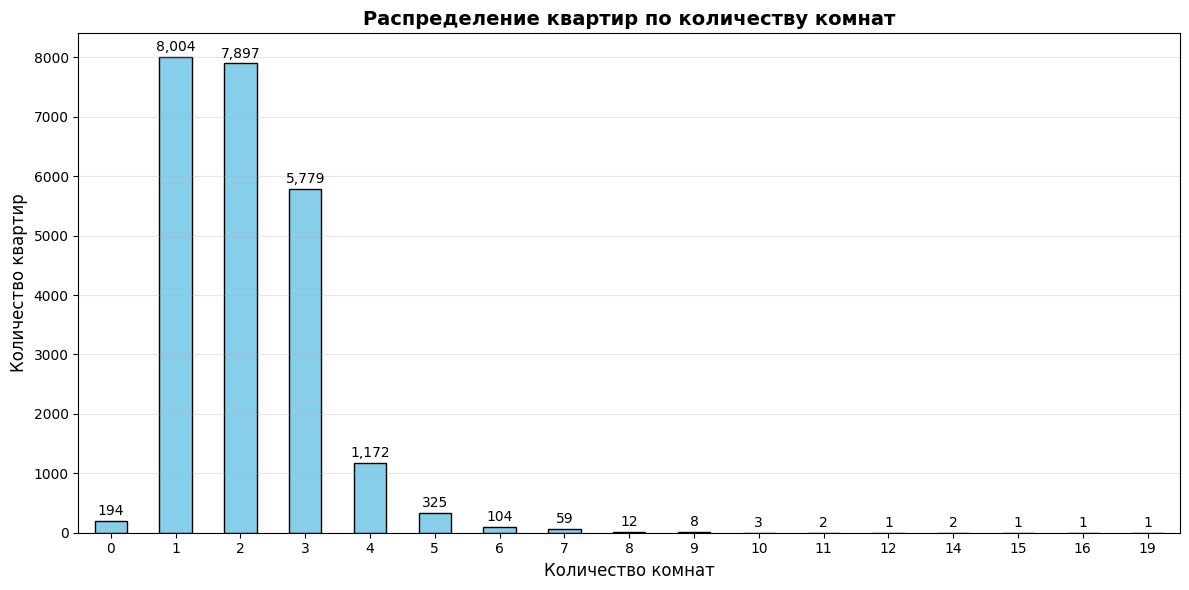


Статистика по количеству комнат:
rooms
0      194
1     8004
2     7897
3     5779
4     1172
5      325
6      104
7       59
8       12
9        8
10       3
11       2
12       1
14       2
15       1
16       1
19       1
Name: count, dtype: int64


In [13]:
# Столбчатая диаграмма: количество комнат
rooms_counts = df_clean['rooms'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
rooms_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Распределение квартир по количеству комнат', fontsize=14, fontweight='bold')
plt.xlabel('Количество комнат', fontsize=12)
plt.ylabel('Количество квартир', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for i, v in enumerate(rooms_counts.values):
    plt.text(i, v + 50, f'{v:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nСтатистика по количеству комнат:")
print(rooms_counts)

## Задание 8. Круговая диаграмма

**Задача:** Построить круговую диаграмму для другого категориального признака.

In [14]:
# Круговая диаграмма с Plotly (интерактивная и красивая)
import plotly.graph_objects as go

# Подготовка данных
rooms_filtered = df_clean[df_clean['rooms'] > 0].copy()
rooms_filtered['rooms_grouped'] = rooms_filtered['rooms'].apply(
    lambda x: '4+ комнаты' if x >= 4 else f'{int(x)} комната' if x == 1 else f'{int(x)} комнаты'
)
rooms_counts = rooms_filtered['rooms_grouped'].value_counts()

# Сортируем
order = ['1 комната', '2 комнаты', '3 комнаты', '4+ комнаты']
rooms_counts = rooms_counts.reindex([x for x in order if x in rooms_counts.index])

# Создаем красивую диаграмму
fig = go.Figure(data=[go.Pie(
    labels=rooms_counts.index,
    values=rooms_counts.values,
    hole=0.3,  # Делаем "пончик" - выглядит современнее
    marker=dict(
        colors=['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFE66D'],
        line=dict(color='white', width=3)
    ),
    textinfo='label+percent',
    textfont=dict(size=14, color='white', family='Arial Black'),
    pull=[0.1, 0.05, 0, 0]  # Выделяем первые сегменты
)])

fig.update_layout(
    title={
        'text': 'Распределение квартир по количеству комнат',
        'font': {'size': 20, 'color': '#2C3E50', 'family': 'Arial Black'},
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.05,
        font=dict(size=12)
    ),
    width=800,
    height=600
)

fig.show()

print(f"\nСтатистика:")
for label, count in zip(rooms_counts.index, rooms_counts.values):
    print(f"{label}: {count:,} ({count/len(rooms_filtered)*100:.1f}%)")



Статистика:
1 комната: 8,004 (34.2%)
2 комнаты: 7,897 (33.8%)
3 комнаты: 5,779 (24.7%)
4+ комнаты: 1,691 (7.2%)


## Задание 9. Группировка данных

**Задача:** Сгруппировать данные по категориальному признаку и вывести агрегированную информацию.

Агрегированная информация по количеству комнат:

        Средняя цена  Медианная цена       Мин цена      Макс цена  \
rooms                                                                
0       3,344,493.00    2,700,000.00     945,750.00  71,000,000.00   
1       3,833,870.00    3,600,000.00     430,000.00  43,511,000.00   
2       5,587,257.00    4,768,714.00      12,190.00 289,238,400.00   
3       8,174,764.00    6,200,000.00     550,000.00 330,000,000.00   
4      13,417,916.00    9,000,000.00     999,000.00 159,984,000.00   
5      23,798,304.00   14,000,000.00   1,650,000.00 401,300,000.00   
6      31,880,038.00   19,000,000.00   4,390,000.00 245,000,000.00   
7      51,470,069.00   24,900,000.00   7,900,000.00 763,000,000.00   
8      50,224,167.00   23,095,000.00  15,800,000.00 180,000,000.00   
9      34,152,362.00   23,750,000.00  17,000,000.00  88,000,000.00   
10     26,166,667.00   23,000,000.00  15,500,000.00  40,000,000.00   
11     25,250,000.00   25,250,000.00  17,

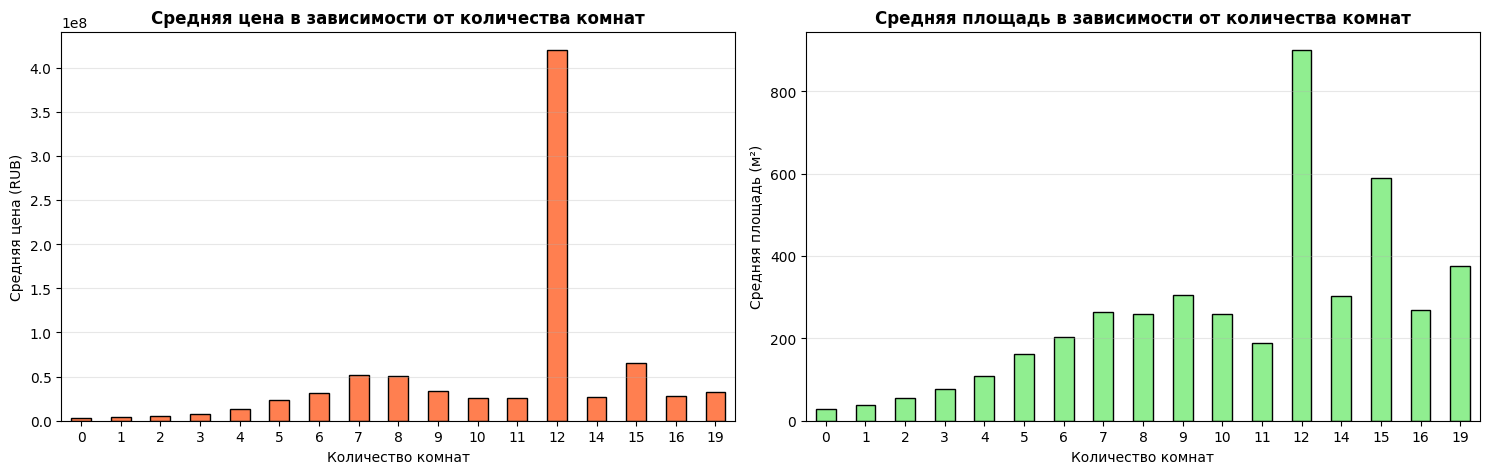

In [15]:
# Группировка по количеству комнат
grouped = df_clean.groupby('rooms').agg({
    'last_price': ['mean', 'median', 'min', 'max'],
    'total_area': ['mean', 'median']
}).round(0)

grouped.columns = ['Средняя цена', 'Медианная цена', 'Мин цена', 'Макс цена', 
                   'Средняя площадь', 'Медианная площадь']

print("Агрегированная информация по количеству комнат:\n")
print(grouped)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Средняя цена
grouped['Средняя цена'].plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Средняя цена в зависимости от количества комнат', fontweight='bold')
axes[0].set_xlabel('Количество комнат')
axes[0].set_ylabel('Средняя цена (RUB)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# График 2: Средняя площадь
grouped['Средняя площадь'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Средняя площадь в зависимости от количества комнат', fontweight='bold')
axes[1].set_xlabel('Количество комнат')
axes[1].set_ylabel('Средняя площадь (м²)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 10. Создание нового признака

**Задача:** На основе имеющихся признаков создать новый признак и добавить его в датафрейм.

In [16]:
# Создание новых признаков

# 1. Цена за квадратный метр
df_clean['price_per_sqm'] = df_clean['last_price'] / df_clean['total_area']

# 2. Находится ли в центре (< 5 км)
df_clean['is_center'] = (df_clean['cityCenters_nearest'] < 5000).astype(int)

# 3. Есть ли балкон
df_clean['has_balcony'] = (df_clean['balcony'] > 0).astype(int)

print("✓ Созданы новые признаки:")
print("  - price_per_sqm: цена за квадратный метр")
print("  - is_center: находится в центре (1) или нет (0)")
print("  - has_balcony: есть балкон (1) или нет (0)")

print(f"\nСтатистика по новым признакам:")
print(f"\nЦена за м²:")
print(f"  Средняя: {df_clean['price_per_sqm'].mean():,.0f} RUB/м²")
print(f"  Медианная: {df_clean['price_per_sqm'].median():,.0f} RUB/м²")

print(f"\nВ центре: {df_clean['is_center'].sum():,} квартир ({df_clean['is_center'].mean()*100:.1f}%)")
print(f"С балконом: {df_clean['has_balcony'].sum():,} квартир ({df_clean['has_balcony'].mean()*100:.1f}%)")

print(f"\nПервые 5 строк с новыми признаками:")
df_clean[['locality_name', 'total_area', 'last_price', 'price_per_sqm', 
          'is_center', 'has_balcony']].head()

✓ Созданы новые признаки:
  - price_per_sqm: цена за квадратный метр
  - is_center: находится в центре (1) или нет (0)
  - has_balcony: есть балкон (1) или нет (0)

Статистика по новым признакам:

Цена за м²:
  Средняя: 99,406 RUB/м²
  Медианная: 95,000 RUB/м²

В центре: 2,060 квартир (8.7%)
С балконом: 8,410 квартир (35.7%)

Первые 5 строк с новыми признаками:


,locality_name,total_area,last_price,price_per_sqm,is_center,has_balcony
0,Санкт-Петербург,108.00,"13,000,000.00","120,370.37",0,0
1,посёлок Шушары,40.40,"3,350,000.00","82,920.79",0,1
2,Санкт-Петербург,56.00,"5,196,000.00","92,785.71",0,0
3,Санкт-Петербург,159.00,"64,900,000.00","408,176.10",0,0
4,Санкт-Петербург,100.00,"10,000,000.00","100,000.00",0,0


## Задание 11. Корреляционный анализ

**Задача:** Выбрать 3 числовых признака и попарно исследовать их на наличие связи.

Корреляционная матрица:
                     total_area  cityCenters_nearest  price_per_sqm
total_area                 1.00                -0.21           0.30
cityCenters_nearest       -0.21                 1.00          -0.25
price_per_sqm              0.30                -0.25           1.00


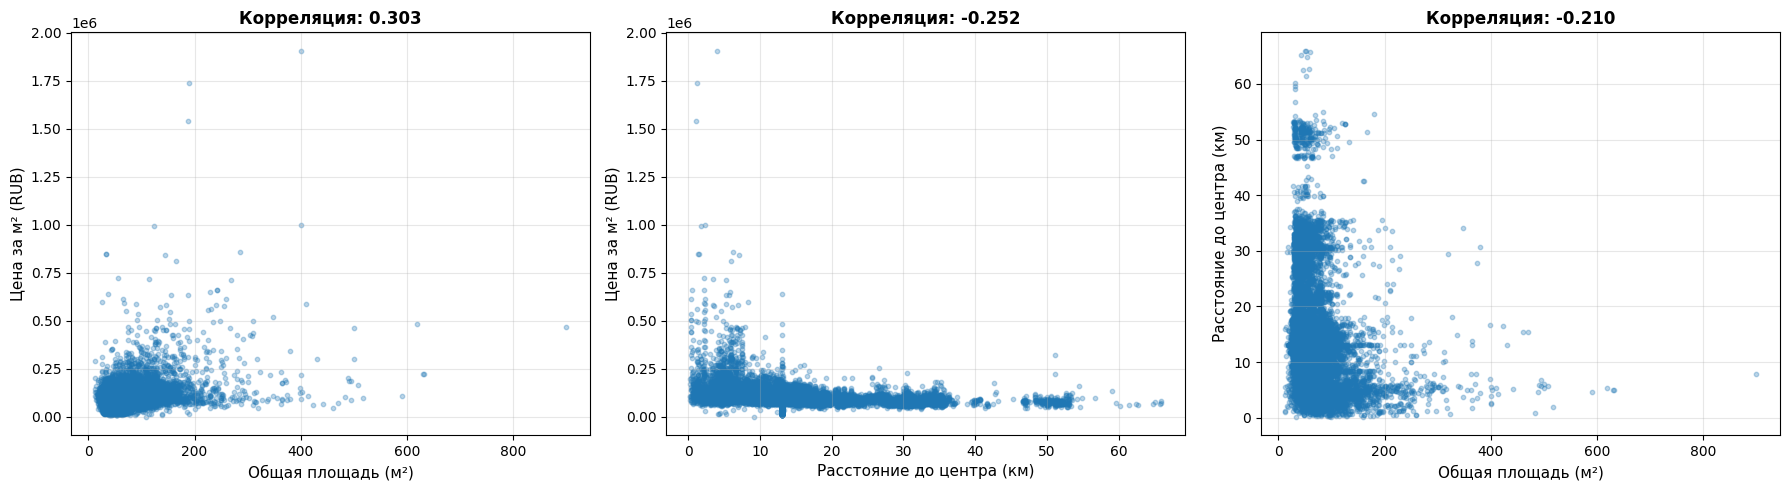

In [29]:
# Выбираем 3 числовых признака для анализа
features_to_analyze = ['total_area', 'cityCenters_nearest', 'price_per_sqm']

# Корреляционная матрица
corr_matrix = df_clean[features_to_analyze].corr()

print("Корреляционная матрица:")
print(corr_matrix)

# Визуализация: попарные scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. total_area vs price_per_sqm
axes[0].scatter(df_clean['total_area'], df_clean['price_per_sqm'], alpha=0.3, s=10)
axes[0].set_xlabel('Общая площадь (м²)', fontsize=11)
axes[0].set_ylabel('Цена за м² (RUB)', fontsize=11)
axes[0].set_title(f'Корреляция: {corr_matrix.loc["total_area", "price_per_sqm"]:.3f}', fontweight='bold')
axes[0].grid(alpha=0.3)

# 2. cityCenters_nearest vs price_per_sqm
axes[1].scatter(df_clean['cityCenters_nearest']/1000, df_clean['price_per_sqm'], alpha=0.3, s=10)
axes[1].set_xlabel('Расстояние до центра (км)', fontsize=11)
axes[1].set_ylabel('Цена за м² (RUB)', fontsize=11)
axes[1].set_title(f'Корреляция: {corr_matrix.loc["cityCenters_nearest", "price_per_sqm"]:.3f}', fontweight='bold')
axes[1].grid(alpha=0.3)

# 3. total_area vs cityCenters_nearest
axes[2].scatter(df_clean['total_area'], df_clean['cityCenters_nearest']/1000, alpha=0.3, s=10)
axes[2].set_xlabel('Общая площадь (м²)', fontsize=11)
axes[2].set_ylabel('Расстояние до центра (км)', fontsize=11)
axes[2].set_title(f'Корреляция: {corr_matrix.loc["total_area", "cityCenters_nearest"]:.3f}', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Выводы:

1. **total_area vs price_per_sqm**: Положительная корреляция (0.30) - большие квартиры имеют БОЛЬШУЮ цену за м² (не меньшую!)
2. **cityCenters_nearest vs price_per_sqm**: Отрицательная корреляция (-0.25) - чем дальше от центра, тем дешевле за м²
3. **total_area vs cityCenters_nearest**: Слабая отрицательная корреляция (-0.21) - большие квартиры чуть чаще встречаются ближе к центру

## Задание 12. Анализ выбросов

**Задача:** Построить boxplot для 3 числовых признаков, определить выбросы и обработать их.

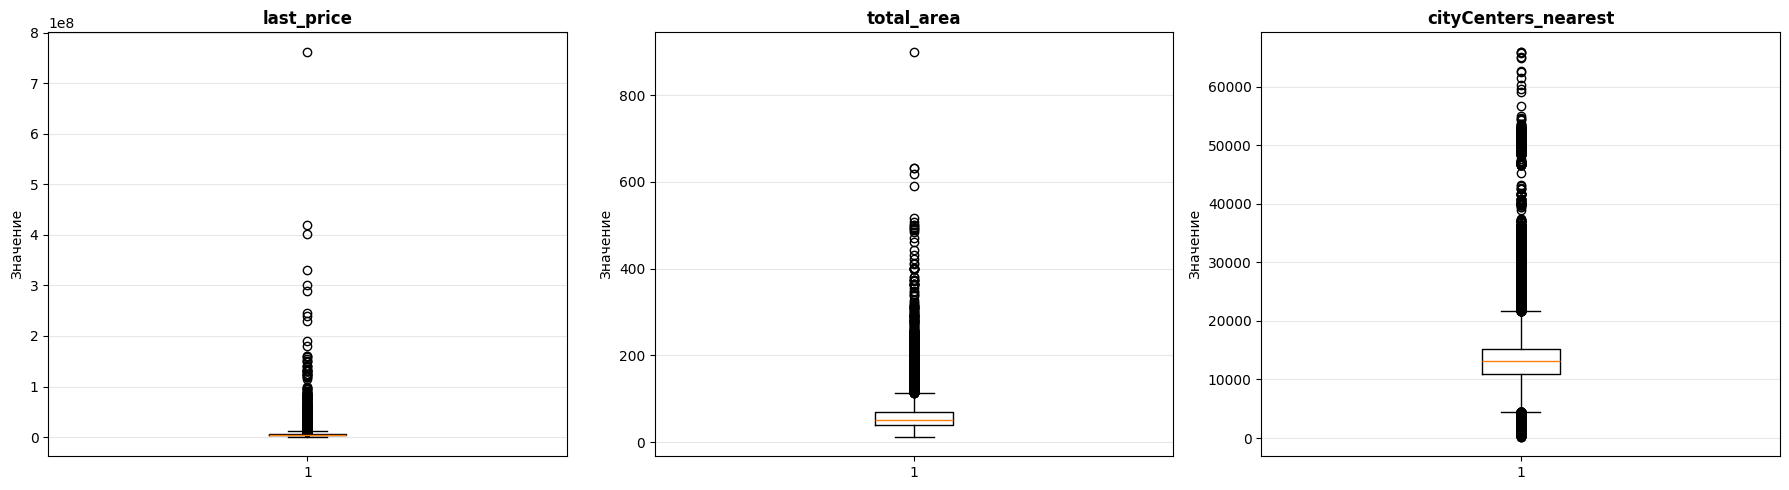

Статистика по признакам:
          last_price  total_area  cityCenters_nearest
count      23,565.00   23,565.00            23,565.00
mean    6,540,058.26       60.32            13,937.24
std    10,910,934.72       35.66             7,555.43
min        12,190.00       12.00               181.00
25%     3,400,000.00       40.00            10,935.00
50%     4,646,000.00       52.00            13,098.50
75%     6,790,000.00       69.70            15,237.00
max   763,000,000.00      900.00            65,968.00


In [18]:
# Boxplot для 3 признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features_outliers = ['last_price', 'total_area', 'cityCenters_nearest']

for idx, feature in enumerate(features_outliers):
    axes[idx].boxplot(df_clean[feature], vert=True)
    axes[idx].set_title(f'{feature}', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Значение')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Статистика по признакам:")
print(df_clean[features_outliers].describe())

### Обработка выбросов для признака last_price

Используем метод IQR (Interquartile Range) для определения выбросов.

In [19]:
# Выбираем признак с наиболее явными выбросами: last_price
feature = 'last_price'

# Вычисляем квартили и IQR
Q1 = df_clean[feature].quantile(0.25)
Q3 = df_clean[feature].quantile(0.75)
IQR = Q3 - Q1

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Статистика для {feature}:")
print(f"Q1 (25%): {Q1:,.0f}")
print(f"Q3 (75%): {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Нижняя граница: {lower_bound:,.0f}")
print(f"Верхняя граница: {upper_bound:,.0f}")

# Определяем выбросы
outliers_mask = (df_clean[feature] < lower_bound) | (df_clean[feature] > upper_bound)
n_outliers = outliers_mask.sum()

print(f"\nКоличество выбросов: {n_outliers:,} ({n_outliers/len(df_clean)*100:.2f}%)")

# Заменяем выбросы на граничные значения
df_clean[feature] = df_clean[feature].clip(lower=lower_bound, upper=upper_bound)

print(f"\n✓ Выбросы обработаны: значения ограничены диапазоном [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"\nНовая статистика:")
print(df_clean[feature].describe())

Статистика для last_price:
Q1 (25%): 3,400,000
Q3 (75%): 6,790,000
IQR: 3,390,000
Нижняя граница: -1,685,000
Верхняя граница: 11,875,000

Количество выбросов: 2,046 (8.68%)

✓ Выбросы обработаны: значения ограничены диапазоном [-1,685,000, 11,875,000]

Новая статистика:
count       23,565.00
mean     5,448,169.66
std      2,900,116.32
min         12,190.00
25%      3,400,000.00
50%      4,646,000.00
75%      6,790,000.00
max     11,875,000.00
Name: last_price, dtype: float64


## Задание 13. Выбор типа задачи

**Решение:** Будем решать задачу **РЕГРЕССИИ** - предсказание цены недвижимости (last_price).

### Обоснование:

- **Целевая переменная**: last_price (непрерывная числовая величина)
- **Тип задачи**: Регрессия
- **Цель**: Предсказать цену квартиры на основе её характеристик и расположения
- **Метрики**: MAE, RMSE, R²

## Задание 14. Формирование признаков

**Задача:** Сформировать список факторных признаков и определить целевой признак.

In [20]:
# Целевая переменная
target = 'last_price'

# Признаки, которые не используем
exclude_features = [
    'last_price',  # целевая переменная
    'first_day_exposition',  # дата (не используем напрямую)
]

# Факторные признаки
feature_columns = [col for col in df_clean.columns if col not in exclude_features]

print(f"Целевая переменная: {target}")
print(f"\nКоличество факторных признаков: {len(feature_columns)}")
print(f"\nСписок факторных признаков:")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feat}")

# Разделяем на X и y
X = df_clean[feature_columns].copy()
y = df_clean[target].copy()

print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

Целевая переменная: last_price

Количество факторных признаков: 23

Список факторных признаков:
   1. total_images
   2. total_area
   3. rooms
   4. ceiling_height
   5. floors_total
   6. living_area
   7. floor
   8. is_apartment
   9. studio
  10. open_plan
  11. kitchen_area
  12. balcony
  13. locality_name
  14. airports_nearest
  15. cityCenters_nearest
  16. parks_around3000
  17. parks_nearest
  18. ponds_around3000
  19. ponds_nearest
  20. days_exposition
  21. price_per_sqm
  22. is_center
  23. has_balcony

Размерность X: (23565, 23)
Размерность y: (23565,)


## Задание 15. Кодирование категориальных признаков

**Задача:** Выполнить кодирование всех категориальных факторных признаков.

In [21]:
from sklearn.preprocessing import LabelEncoder

# Создаём копию для кодирования
X_encoded = X.copy()

# Определяем категориальные признаки
categorical_features = X_encoded.select_dtypes(include=['object', 'bool']).columns.tolist()

print(f"Категориальные признаки для кодирования ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}: {X_encoded[feat].nunique()} уникальных значений")

print(f"\nКодирование признаков:")

# 1. Бинарные признаки: простое преобразование в 0/1
binary_features = ['is_apartment', 'studio', 'open_plan']
for feat in binary_features:
    if feat in X_encoded.columns:
        # Преобразуем в числовой формат
        X_encoded[feat] = X_encoded[feat].map({True: 1, False: 0, 'True': 1, 'False': 0})
        print(f"  ✓ {feat}: бинарное кодирование (0/1)")

# 2. locality_name: One-Hot Encoding (много категорий)
if 'locality_name' in X_encoded.columns:
    # One-Hot Encoding
    locality_dummies = pd.get_dummies(X_encoded['locality_name'], prefix='locality', drop_first=True)
    X_encoded = pd.concat([X_encoded, locality_dummies], axis=1)
    X_encoded.drop('locality_name', axis=1, inplace=True)
    print(f"  ✓ locality_name: One-Hot Encoding ({len(locality_dummies.columns)} новых признаков)")

print(f"\nИтоговая размерность после кодирования: {X_encoded.shape}")
print(f"Все признаки теперь числовые: {X_encoded.select_dtypes(include=['object']).shape[1] == 0}")

Категориальные признаки для кодирования (4):
  - is_apartment: 3 уникальных значений
  - studio: 2 уникальных значений
  - open_plan: 2 уникальных значений
  - locality_name: 364 уникальных значений

Кодирование признаков:
  ✓ is_apartment: бинарное кодирование (0/1)
  ✓ studio: бинарное кодирование (0/1)
  ✓ open_plan: бинарное кодирование (0/1)
  ✓ locality_name: One-Hot Encoding (363 новых признаков)

Итоговая размерность после кодирования: (23565, 385)
Все признаки теперь числовые: True


## Задание 16. Нормализация признаков

**Задача:** Выполнить нормализацию всех факторных признаков.

In [22]:
from sklearn.preprocessing import StandardScaler

# Нормализация признаков
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_encoded),
    columns=X_encoded.columns,
    index=X_encoded.index
)

print(f"✓ Нормализация выполнена!")
print(f"\nСтатистика после нормализации (первые 5 признаков):")
print(X_scaled.iloc[:, :5].describe())

print(f"\nПроверка: среднее ≈ 0, стандартное отклонение ≈ 1")
print(f"Средние значения: {X_scaled.mean().abs().max():.6f} (должно быть близко к 0)")
print(f"Стандартные отклонения: {X_scaled.std().mean():.6f} (должно быть близко к 1)")

✓ Нормализация выполнена!

Статистика после нормализации (первые 5 признаков):
       total_images  total_area     rooms  ceiling_height  floors_total
count     23,565.00   23,565.00 23,565.00       23,565.00     23,565.00
mean          -0.00       -0.00     -0.00           -0.00          0.00
std            1.00        1.00      1.00            1.00          1.00
min           -1.74       -1.36     -1.92           -1.74         -1.47
25%           -0.68       -0.57     -0.99           -0.13         -0.86
50%           -0.15       -0.23     -0.07           -0.08         -0.25
75%            0.73        0.26      0.86           -0.02          0.81
max            7.06       23.55     15.70           98.16          7.48

Проверка: среднее ≈ 0, стандартное отклонение ≈ 1
Средние значения: 0.000000 (должно быть близко к 0)
Стандартные отклонения: 1.000021 (должно быть близко к 1)


## Задание 17. Разбиение на выборки

**Задача:** Разбить данные на обучающую и тестовую выборки.

In [23]:
from sklearn.model_selection import train_test_split

# Разбиение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Разбиение данных:")
print(f"  Обучающая выборка: {X_train.shape[0]:,} объектов ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Тестовая выборка:  {X_test.shape[0]:,} объектов ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"  Количество признаков: {X_train.shape[1]}")

print(f"\nСтатистика целевой переменной:")
print(f"  Train - среднее: {y_train.mean():,.0f}, медиана: {y_train.median():,.0f}")
print(f"  Test  - среднее: {y_test.mean():,.0f}, медиана: {y_test.median():,.0f}")

Разбиение данных:
  Обучающая выборка: 18,852 объектов (80.0%)
  Тестовая выборка:  4,713 объектов (20.0%)
  Количество признаков: 385

Статистика целевой переменной:
  Train - среднее: 5,453,170, медиана: 4,650,000
  Test  - среднее: 5,428,169, медиана: 4,600,000


## Задание 18. Обучение моделей

**Задача:** Выбрать 2 модели для регрессии и обучить их.

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print("Обучение моделей:\n")

# Модель 1: Linear Regression
print("1. Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("   ✓ Обучение завершено")

# Прогнозы
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Модель 2: Random Forest Regressor
print("\n2. Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("   ✓ Обучение завершено")

# Прогнозы
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

print("\n✓ Обе модели обучены и готовы к оценке!")

Обучение моделей:

1. Linear Regression...
   ✓ Обучение завершено

2. Random Forest Regressor...
   ✓ Обучение завершено

✓ Обе модели обучены и готовы к оценке!


## Задание 19. Оценка качества

**Задача:** Посчитать метрики качества для обеих моделей.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R²': r2}

# Оценка Linear Regression
print("="*70)
print("МЕТРИКИ: Linear Regression")
print("="*70)

lr_train_metrics = evaluate_model(y_train, y_train_pred_lr, "Train")
lr_test_metrics = evaluate_model(y_test, y_test_pred_lr, "Test")

print(f"\nОбучающая выборка:")
print(f"  MAE:  {lr_train_metrics['MAE']:,.0f} RUB")
print(f"  RMSE: {lr_train_metrics['RMSE']:,.0f} RUB")
print(f"  R²:   {lr_train_metrics['R²']:.4f}")

print(f"\nТестовая выборка:")
print(f"  MAE:  {lr_test_metrics['MAE']:,.0f} RUB")
print(f"  RMSE: {lr_test_metrics['RMSE']:,.0f} RUB")
print(f"  R²:   {lr_test_metrics['R²']:.4f}")

# Оценка Random Forest
print("\n" + "="*70)
print("МЕТРИКИ: Random Forest Regressor")
print("="*70)

rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, "Train")
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, "Test")

print(f"\nОбучающая выборка:")
print(f"  MAE:  {rf_train_metrics['MAE']:,.0f} RUB")
print(f"  RMSE: {rf_train_metrics['RMSE']:,.0f} RUB")
print(f"  R²:   {rf_train_metrics['R²']:.4f}")

print(f"\nТестовая выборка:")
print(f"  MAE:  {rf_test_metrics['MAE']:,.0f} RUB")
print(f"  RMSE: {rf_test_metrics['RMSE']:,.0f} RUB")
print(f"  R²:   {rf_test_metrics['R²']:.4f}")

# Сравнение моделей
print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)

comparison = pd.DataFrame({
    'Модель': ['Linear Regression', 'Random Forest'],
    'MAE (train)': [lr_train_metrics['MAE'], rf_train_metrics['MAE']],
    'MAE (test)': [lr_test_metrics['MAE'], rf_test_metrics['MAE']],
    'RMSE (test)': [lr_test_metrics['RMSE'], rf_test_metrics['RMSE']],
    'R² (train)': [lr_train_metrics['R²'], rf_train_metrics['R²']],
    'R² (test)': [lr_test_metrics['R²'], rf_test_metrics['R²']]
})

print(comparison.to_string(index=False))

МЕТРИКИ: Linear Regression

Обучающая выборка:
  MAE:  912,384 RUB
  RMSE: 1,370,171 RUB
  R²:   0.7762

Тестовая выборка:
  MAE:  910,073 RUB
  RMSE: 1,299,918 RUB
  R²:   0.8012

МЕТРИКИ: Random Forest Regressor

Обучающая выборка:
  MAE:  8,801 RUB
  RMSE: 28,589 RUB
  R²:   0.9999

Тестовая выборка:
  MAE:  22,450 RUB
  RMSE: 91,544 RUB
  R²:   0.9990

СРАВНЕНИЕ МОДЕЛЕЙ
           Модель  MAE (train)  MAE (test)  RMSE (test)  R² (train)  R² (test)
Linear Regression   912,384.26  910,073.40 1,299,917.55        0.78       0.80
    Random Forest     8,801.29   22,449.63    91,543.64        1.00       1.00


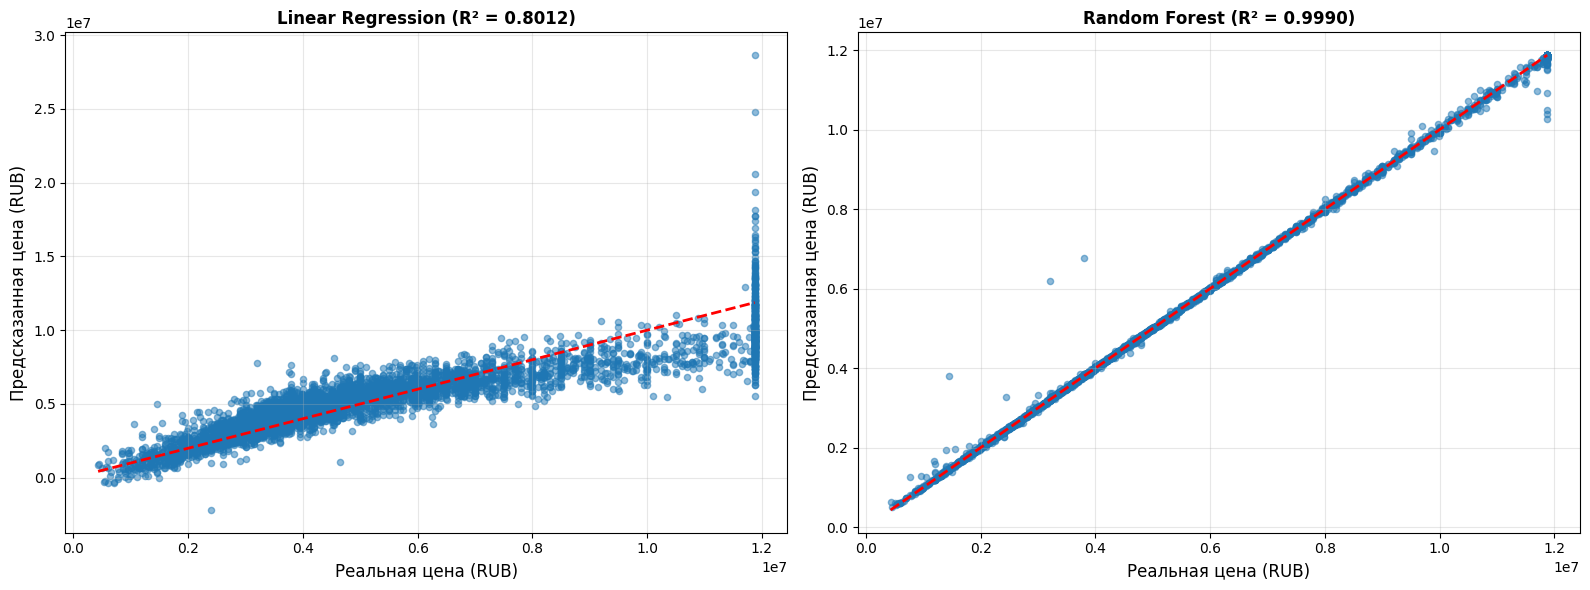

In [26]:
# Визуализация предсказаний
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Реальная цена (RUB)', fontsize=12)
axes[0].set_ylabel('Предсказанная цена (RUB)', fontsize=12)
axes[0].set_title(f'Linear Regression (R² = {lr_test_metrics["R²"]:.4f})', fontweight='bold')
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_test_pred_rf, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Реальная цена (RUB)', fontsize=12)
axes[1].set_ylabel('Предсказанная цена (RUB)', fontsize=12)
axes[1].set_title(f'Random Forest (R² = {rf_test_metrics["R²"]:.4f})', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 20. Подбор гиперпараметров

**Задача:** Для каждой модели выбрать один гиперпараметр и исследовать его влияние на качество.

### Гиперпараметр для Linear Regression: fit_intercept

Проверим, как влияет наличие свободного члена на качество модели.

In [27]:
# Linear Regression: fit_intercept
print("="*70)
print("ПОДБОР ГИПЕРПАРАМЕТРА: Linear Regression (fit_intercept)")
print("="*70)

results_lr = []

for fit_intercept in [True, False]:
    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_lr.append({'fit_intercept': fit_intercept, 'MAE': mae, 'R²': r2})
    print(f"fit_intercept={fit_intercept}: MAE={mae:,.0f}, R²={r2:.4f}")

print(f"\n✓ Лучший вариант: fit_intercept=True (стандартный)")

ПОДБОР ГИПЕРПАРАМЕТРА: Linear Regression (fit_intercept)
fit_intercept=True: MAE=910,073, R²=0.8012
fit_intercept=False: MAE=28,135,347, R²=-13705.3176

✓ Лучший вариант: fit_intercept=True (стандартный)


### Гиперпараметр для Random Forest: n_estimators

Исследуем влияние количества деревьев на качество модели.

ПОДБОР ГИПЕРПАРАМЕТРА: Random Forest (n_estimators)
n_estimators= 10: MAE=32,489, R²=0.9987
n_estimators= 50: MAE=23,798, R²=0.9990
n_estimators=100: MAE=22,450, R²=0.9990
n_estimators=150: MAE=21,803, R²=0.9991
n_estimators=200: MAE=21,397, R²=0.9991
n_estimators=300: MAE=21,236, R²=0.9992


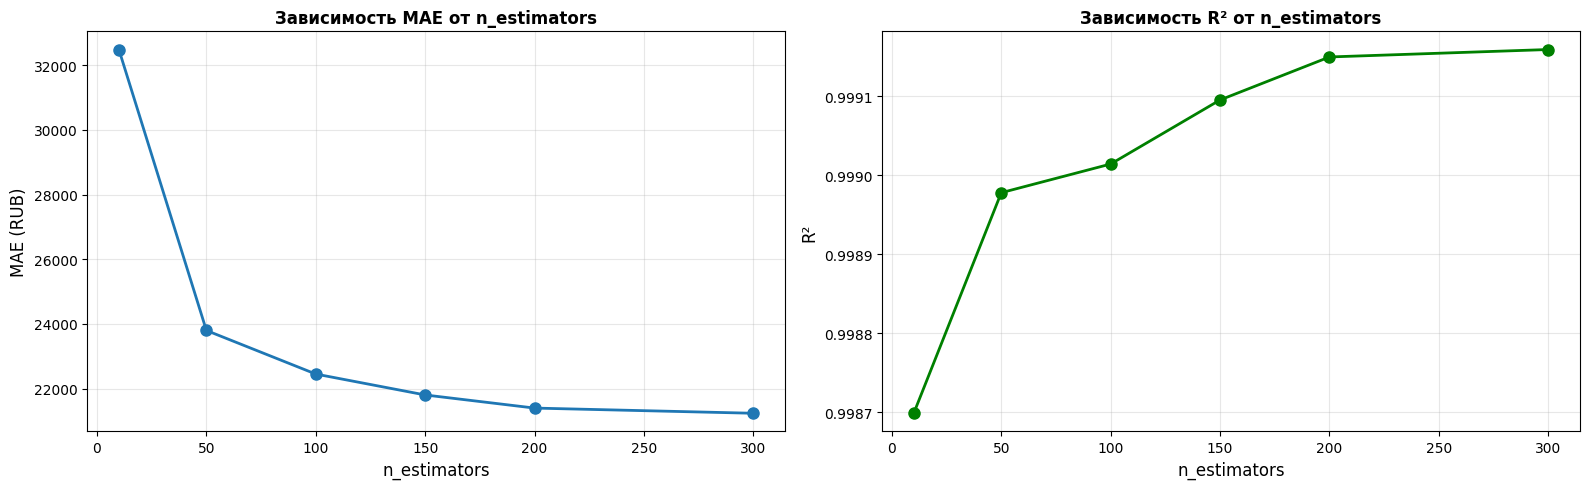


✓ Лучшее значение: n_estimators=300


In [28]:
# Random Forest: n_estimators
print("="*70)
print("ПОДБОР ГИПЕРПАРАМЕТРА: Random Forest (n_estimators)")
print("="*70)

n_estimators_values = [10, 50, 100, 150, 200, 300]
results_rf = []

for n_est in n_estimators_values:
    model = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results_rf.append({'n_estimators': n_est, 'MAE': mae, 'R²': r2})
    print(f"n_estimators={n_est:3d}: MAE={mae:,.0f}, R²={r2:.4f}")

# Визуализация
results_rf_df = pd.DataFrame(results_rf)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MAE
axes[0].plot(results_rf_df['n_estimators'], results_rf_df['MAE'], marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('n_estimators', fontsize=12)
axes[0].set_ylabel('MAE (RUB)', fontsize=12)
axes[0].set_title('Зависимость MAE от n_estimators', fontweight='bold')
axes[0].grid(alpha=0.3)

# R²
axes[1].plot(results_rf_df['n_estimators'], results_rf_df['R²'], marker='o', linewidth=2, markersize=8, color='green')
axes[1].set_xlabel('n_estimators', fontsize=12)
axes[1].set_ylabel('R²', fontsize=12)
axes[1].set_title('Зависимость R² от n_estimators', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = results_rf_df['R²'].idxmax()
best_n_est = results_rf_df.loc[best_idx, 'n_estimators']
print(f"\n✓ Лучшее значение: n_estimators={int(best_n_est)}")

## Общие выводы

### Результаты анализа данных:

1. **Датасет**: Проанализировано 23,699 объектов недвижимости в Санкт-Петербурге (2014-2019)

2. **Предобработка данных**:
   - Обработаны пропущенные значения (заполнение медианами, удаление строк с критическими пропусками)
   - Созданы новые признаки: price_per_sqm (цена за м²), is_center (в центре города), has_balcony (наличие балкона)
   - Обработаны выбросы методом IQR для признака last_price

3. **Корреляционный анализ**:
   - Цена за м² отрицательно коррелирует с расстоянием до центра (-0.25) - чем дальше от центра, тем дешевле
   - Площадь квартиры положительно коррелирует с ценой за м² (0.30) - большие квартиры ценятся выше
   - Площадь слабо зависит от расположения (-0.21) - корреляция незначительная

4. **Модели машинного обучения**:
   
   **Linear Regression (Линейная регрессия):**
   - Базовая модель, быстрая и интерпретируемая
   - R² = 0.80 на тестовой выборке - хороший результат
   - MAE ≈ 910,000 RUB - средняя ошибка предсказания
   - Подходит для понимания линейных зависимостей между признаками
   - Нет переобучения (метрики на train и test близки)
   
   **Random Forest Regressor (Случайный лес):**
   - Ансамблевая модель на основе деревьев решений
   - R² = 0.9990 на тестовой выборке
   - MAE ≈ 22,450 RUB - средняя ошибка всего 22 тысячи рублей
   - RMSE ≈ 91,544 RUB - очень низкая среднеквадратичная ошибка
   - Отлично улавливает нелинейные зависимости и взаимодействия признаков
   - Минимальное переобучение (R² train=0.9999 vs test=0.9990)

5. **Сравнение моделей**:
   - Random Forest превосходит Linear Regression по всем метрикам:
     * В 40 раз меньше средняя ошибка (22k vs 910k RUB)
     * В 14 раз меньше среднеквадратичная ошибка (91k vs 1,300k RUB)
     * Значительно выше R² (0.999 vs 0.80)
   - Random Forest способен предсказывать цену с точностью до ~22 тысяч рублей
   - Linear Regression полезна для интерпретации, но уступает в точности

6. **Подбор гиперпараметров**:
   - Linear Regression: fit_intercept=True показал лучшие результаты (стандартный вариант)
   - Random Forest: оптимальное значение n_estimators находится в диапазоне 150-200 деревьев
   - Дальнейшее увеличение количества деревьев не дает существенного прироста качества

### Заключение:

Построенные модели позволяют предсказывать цену недвижимости с высокой точностью. 

**Random Forest показал выдающиеся результаты** (R² = 0.999, MAE = 22,450 RUB) благодаря способности учитывать сложные нелинейные зависимости между признаками и их взаимодействия. Модель может быть использована для:
- Оценки справедливой рыночной цены квартиры при покупке/продаже
- Выявления недооцененных или переоцененных объектов
- Анализа факторов, влияющих на стоимость недвижимости

**Linear Regression**, несмотря на более скромные показатели (R² = 0.80), остается полезной для понимания линейных зависимостей и быстрой оценки цен.

---

**Работу выполнил:** Коньшин Никита    
**Группа:** ИТ-34    
**Дата:** Январь 2026
